In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("../data/raw/cumin_all_states_raw.csv")

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Shape: (48141, 12)
Rows: 48,141
Columns: 12

Column names:
['date', 'state', 'market', 'variety', 'grade', 'arrivals', 'unit_of_arrivals', 'min_price', 'max_price', 'modal_price', 'unit_of_price', 'commodity']


In [4]:
df.head()

,date,state,market,variety,grade,arrivals,unit_of_arrivals,min_price,max_price,modal_price,unit_of_price,commodity
0,2020-01-01,Gujarat,Amreli APMC,Cummin Seed(Jeera),FAQ,0.60,Metric Tonnes,13750.00,14550.00,13925.00,Rs./Quintal,Cumin (Jeera)
1,2020-01-01,Gujarat,Bhabhar APMC,Other,FAQ,0.80,Metric Tonnes,13450.00,14310.00,13880.00,Rs./Quintal,Cumin (Jeera)
2,2020-01-01,Gujarat,Bhavnagar APMC,Other,FAQ,0.20,Metric Tonnes,11500.00,13000.00,12250.00,Rs./Quintal,Cumin (Jeera)
3,2020-01-01,Gujarat,Botad APMC,Other,FAQ,4.30,Metric Tonnes,11280.00,15680.00,13480.00,Rs./Quintal,Cumin (Jeera)
4,2020-01-01,Gujarat,Dasada Patadi APMC,Cummin Seed(Jeera),FAQ,0.48,Metric Tonnes,13300.00,14455.00,13877.50,Rs./Quintal,Cumin (Jeera)


In [5]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("Missing Values Percentage:")
print(df.isnull().sum() / len(df) * 100)

Data Types:
date                 object
state                object
market               object
variety              object
grade                object
arrivals            float64
unit_of_arrivals     object
min_price           float64
max_price           float64
modal_price         float64
unit_of_price        object
commodity            object
dtype: object

Missing Values:
date                0
state               0
market              0
variety             0
grade               0
arrivals            0
unit_of_arrivals    0
min_price           0
max_price           0
modal_price         0
unit_of_price       0
commodity           0
dtype: int64
Missing Values Percentage:
date               0.00
state              0.00
market             0.00
variety            0.00
grade              0.00
arrivals           0.00
unit_of_arrivals   0.00
min_price          0.00
max_price          0.00
modal_price        0.00
unit_of_price      0.00
commodity          0.00
dtype: float64


In [6]:
df["date"] = pd.to_datetime(df["date"])

print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total unique dates: {df['date'].nunique()}")
print(f"\nDate column type: {df['date'].dtype}")

Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
Total unique dates: 2058

Date column type: datetime64[ns]


In [7]:
# Extract time-based features from date
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.dayofweek

print("New columns added successfully")
print(df[["date", "year", "month", "month_name", "quarter"]].head())

New columns added successfully
        date  year  month month_name  quarter
0 2020-01-01  2020      1        Jan        1
1 2020-01-01  2020      1        Jan        1
2 2020-01-01  2020      1        Jan        1
3 2020-01-01  2020      1        Jan        1
4 2020-01-01  2020      1        Jan        1


In [8]:
print("Basic Statistics for Price columns:")
print(df[["min_price", "max_price", "modal_price", "arrivals"]].describe())

Basic Statistics for Price columns:
       min_price  max_price  modal_price  arrivals
count   48141.00   48141.00     48141.00  48141.00
mean    17753.78   21934.93     20191.76     40.63
std      8576.72   10668.87      9390.35    145.82
min         0.00       0.00      1000.00      0.01
25%     11500.00   14125.00     12900.00      0.90
50%     16505.00   20155.00     18725.00      3.93
75%     20650.00   24455.00     22755.00     20.40
max     80000.00  550000.00     90000.00   8311.10


In [9]:
print(f"Unique states: {df['state'].nunique()}")
print(f"\nState names:\n{sorted(df['state'].unique())}")
print(f"\nUnique markets: {df['market'].nunique()}")
print(f"\nUnique varieties: {df['variety'].unique()}")
print(f"\nUnique grades: {df['grade'].unique()}")
print(f"\nRecords per state (top 10):")
print(df['state'].value_counts().head(10))

Unique states: 10

State names:
['Assam', 'Chattisgarh', 'Gujarat', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Rajasthan', 'Uttar Pradesh', 'Uttarakhand']

Unique markets: 127

Unique varieties: ['Cummin Seed(Jeera)' 'Other' 'Medium' 'Bold' 'Desi' 'Common' 'Pili'
 'Superfine' 'Cumin-Organic']

Unique grades: ['FAQ' 'Local' 'Grade Range-1' 'Grade Range-2' 'Grade Range-3']

Records per state (top 10):
state
Gujarat           34939
Rajasthan         10943
Maharashtra        1320
Madhya Pradesh      350
Karnataka           257
Kerala              243
Chattisgarh          65
Uttar Pradesh        10
Assam                 9
Uttarakhand           5
Name: count, dtype: int64


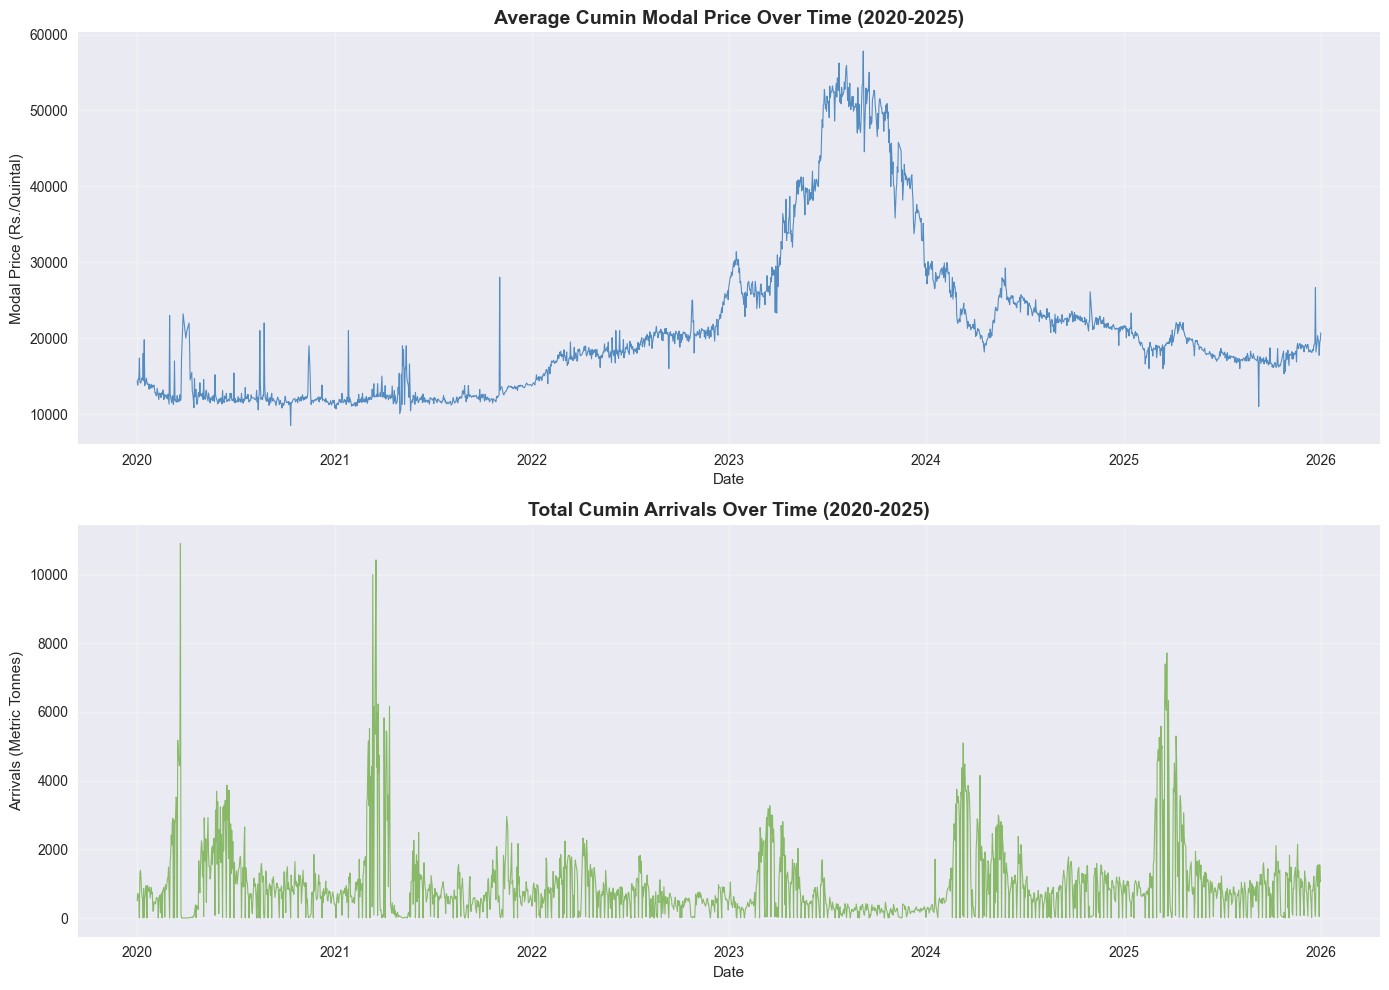

Plot saved to reports/


In [10]:
plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(2,1, figsize=(14,10))
daily_price = df.groupby("date")["modal_price"].mean().reset_index()
axes[0].plot(daily_price["date"], daily_price["modal_price"], color="#2E75B6", linewidth=0.8, alpha=0.8)
axes[0].set_title("Average Cumin Modal Price Over Time (2020-2025)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Modal Price (Rs./Quintal)")
axes[0].grid(True, alpha=0.3)

daily_arrivals = df.groupby("date")["arrivals"].sum().reset_index()
axes[1].plot(daily_arrivals["date"], daily_arrivals["arrivals"], color="#70AD47", linewidth=0.8, alpha=0.8)
axes[1].set_title("Total Cumin Arrivals Over Time (2020-2025)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Arrivals (Metric Tonnes)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/price_and_arrivals_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to reports/")

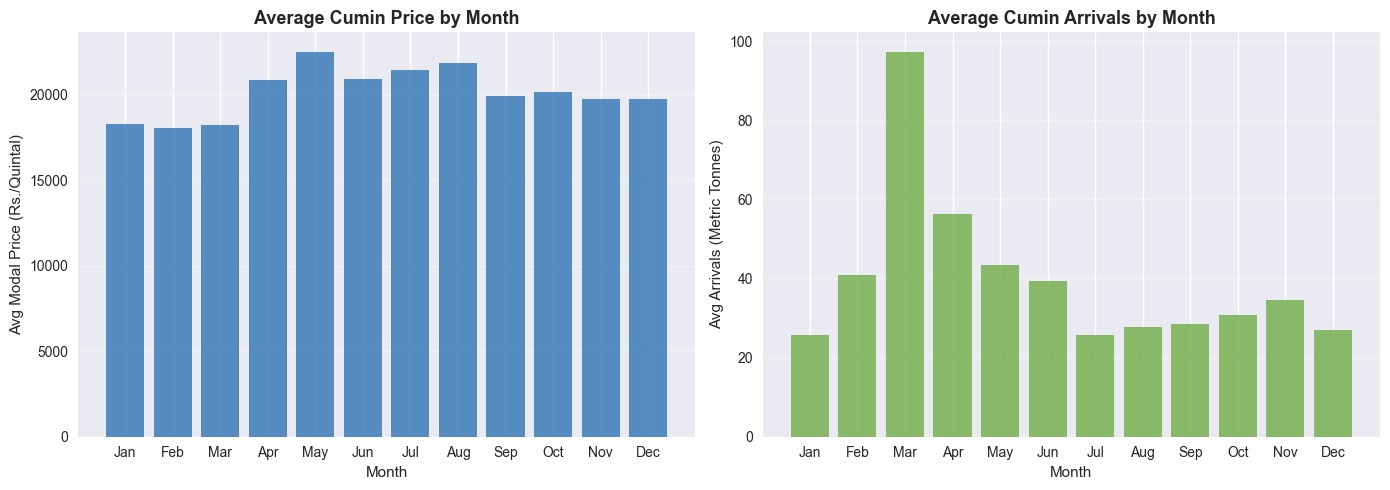

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average price by month
monthly_price = df.groupby("month")["modal_price"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].bar(month_names, monthly_price.values, color="#2E75B6", alpha=0.8)
axes[0].set_title("Average Cumin Price by Month", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Modal Price (Rs./Quintal)")
axes[0].grid(True, alpha=0.3, axis="y")

# Average arrivals by month
monthly_arrivals = df.groupby("month")["arrivals"].mean()
axes[1].bar(month_names, monthly_arrivals.values, color="#70AD47", alpha=0.8)
axes[1].set_title("Average Cumin Arrivals by Month", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Arrivals (Metric Tonnes)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../reports/monthly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

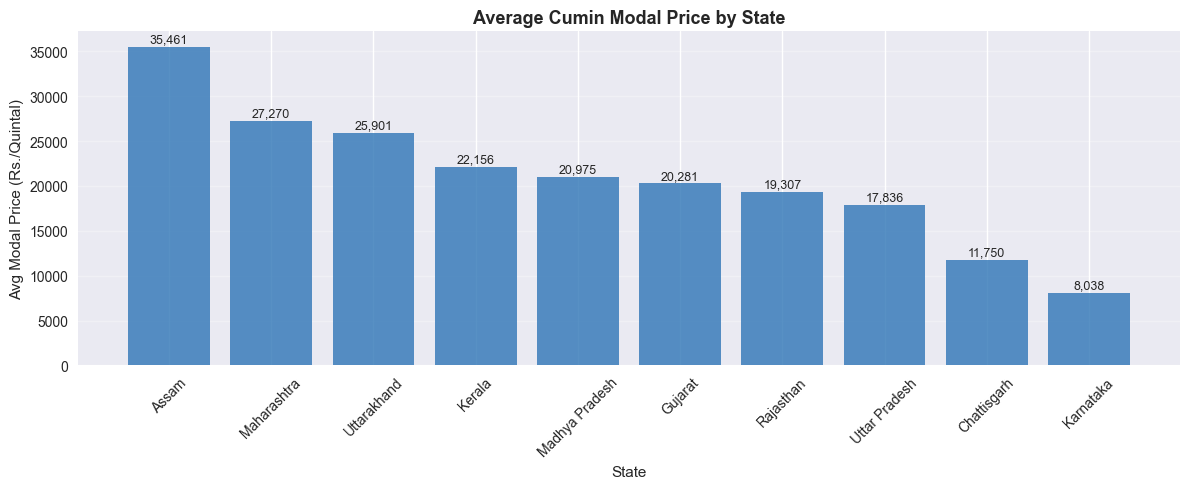

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

state_price = df.groupby("state")["modal_price"].mean().sort_values(ascending=False)
bars = ax.bar(state_price.index, state_price.values, color="#2E75B6", alpha=0.8)
ax.set_title("Average Cumin Modal Price by State", fontsize=13, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Avg Modal Price (Rs./Quintal)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bar, val in zip(bars, state_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/price_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

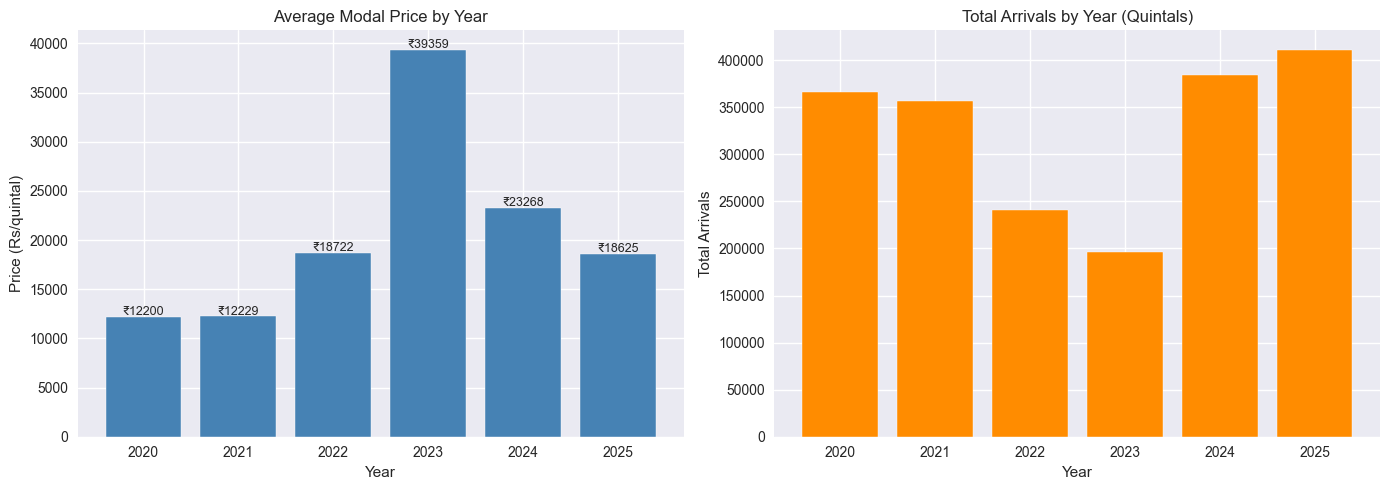

 year  modal_price
 2020     12200.09
 2021     12229.49
 2022     18721.94
 2023     39358.92
 2024     23267.92
 2025     18624.62


In [15]:
# Year-wise comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg modal price by year
yearly_price = df.groupby('year')['modal_price'].mean().reset_index()
axes[0].bar(yearly_price['year'], yearly_price['modal_price'], color='steelblue', edgecolor='white')
axes[0].set_title('Average Modal Price by Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Price (Rs/quintal)')
for i, row in yearly_price.iterrows():
    axes[0].text(row['year'], row['modal_price'] + 200, f"₹{row['modal_price']:.0f}", ha='center', fontsize=9)

# Total arrivals by year
yearly_arrivals = df.groupby('year')['arrivals'].sum().reset_index()
axes[1].bar(yearly_arrivals['year'], yearly_arrivals['arrivals'], color='darkorange', edgecolor='white')
axes[1].set_title('Total Arrivals by Year (Quintals)')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Total Arrivals')

plt.tight_layout()
plt.savefig('../reports/year_wise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(yearly_price.to_string(index=False))

In [17]:
df.head()

,date,state,market,variety,grade,arrivals,unit_of_arrivals,min_price,max_price,modal_price,unit_of_price,commodity,year,month,month_name,quarter,day_of_week
0,2020-01-01,Gujarat,Amreli APMC,Cummin Seed(Jeera),FAQ,0.60,Metric Tonnes,13750.00,14550.00,13925.00,Rs./Quintal,Cumin (Jeera),2020,1,Jan,1,2
1,2020-01-01,Gujarat,Bhabhar APMC,Other,FAQ,0.80,Metric Tonnes,13450.00,14310.00,13880.00,Rs./Quintal,Cumin (Jeera),2020,1,Jan,1,2
2,2020-01-01,Gujarat,Bhavnagar APMC,Other,FAQ,0.20,Metric Tonnes,11500.00,13000.00,12250.00,Rs./Quintal,Cumin (Jeera),2020,1,Jan,1,2
3,2020-01-01,Gujarat,Botad APMC,Other,FAQ,4.30,Metric Tonnes,11280.00,15680.00,13480.00,Rs./Quintal,Cumin (Jeera),2020,1,Jan,1,2
4,2020-01-01,Gujarat,Dasada Patadi APMC,Cummin Seed(Jeera),FAQ,0.48,Metric Tonnes,13300.00,14455.00,13877.50,Rs./Quintal,Cumin (Jeera),2020,1,Jan,1,2


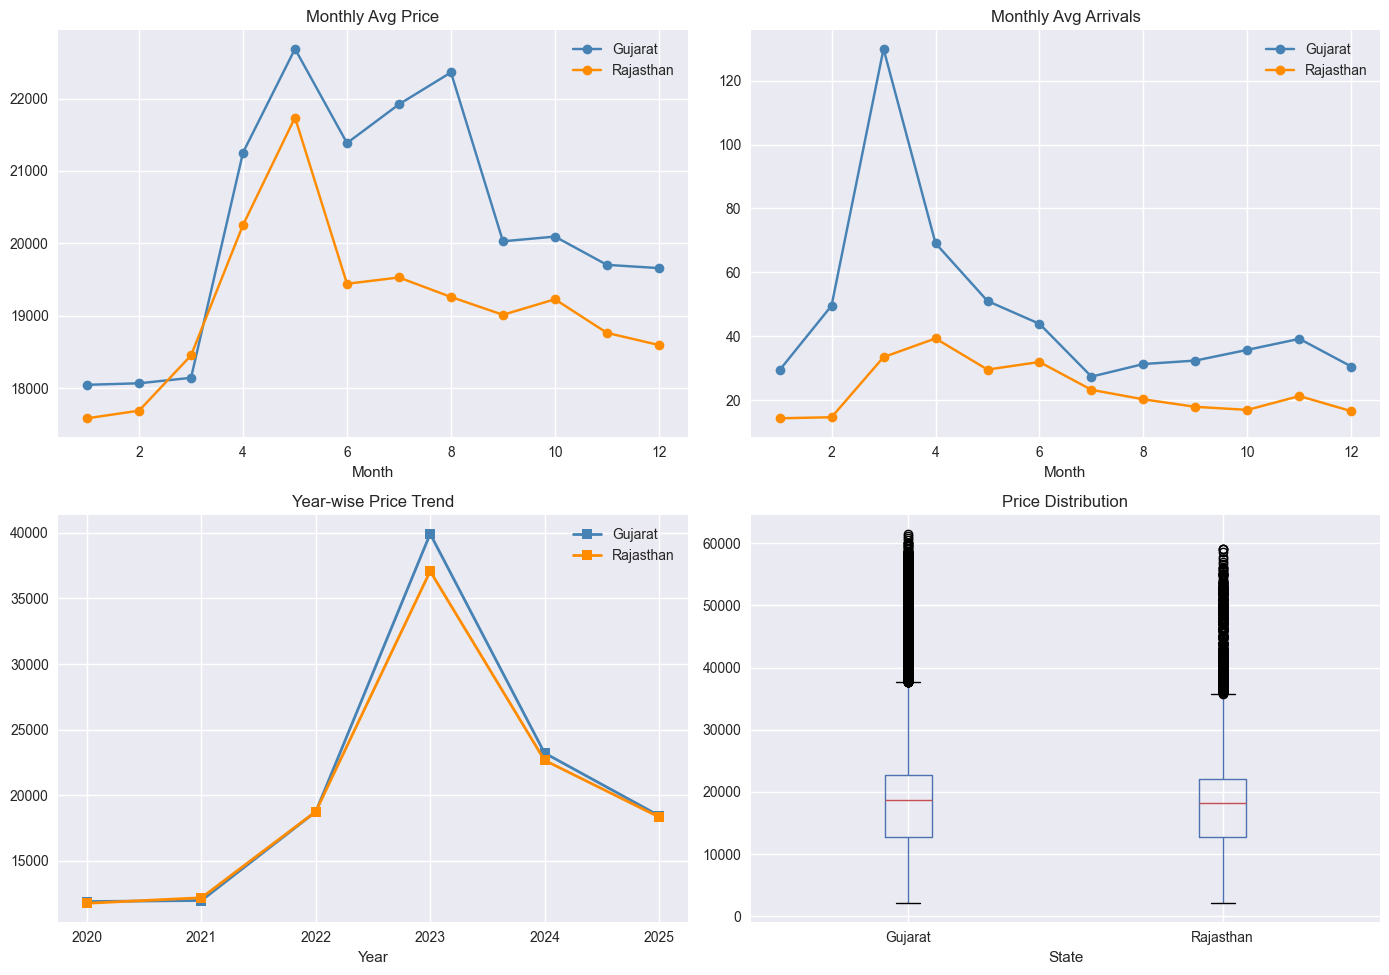

In [18]:
# Gujarat vs Rajasthan comparison (the two producing giants)
guj_raj = df[df['state'].isin(['Gujarat', 'Rajasthan'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gujarat vs Rajasthan Deep Dive', fontsize=14, fontweight='bold')

# Monthly avg price
for state, color in [('Gujarat', 'steelblue'), ('Rajasthan', 'darkorange')]:
    sub = guj_raj[guj_raj['state'] == state]
    monthly = sub.groupby('month')['modal_price'].mean()
    axes[0, 0].plot(monthly.index, monthly.values, marker='o', label=state, color=color)
axes[0, 0].set_title('Monthly Avg Price')
axes[0, 0].set_xlabel('Month'); axes[0, 0].legend()

# Monthly avg arrivals
for state, color in [('Gujarat', 'steelblue'), ('Rajasthan', 'darkorange')]:
    sub = guj_raj[guj_raj['state'] == state]
    monthly = sub.groupby('month')['arrivals'].mean()
    axes[0, 1].plot(monthly.index, monthly.values, marker='o', label=state, color=color)
axes[0, 1].set_title('Monthly Avg Arrivals')
axes[0, 1].set_xlabel('Month'); axes[0, 1].legend()

# Year-wise price trend
for state, color in [('Gujarat', 'steelblue'), ('Rajasthan', 'darkorange')]:
    sub = guj_raj[guj_raj['state'] == state]
    yearly = sub.groupby('year')['modal_price'].mean()
    axes[1, 0].plot(yearly.index, yearly.values, marker='s', label=state, color=color, linewidth=2)
axes[1, 0].set_title('Year-wise Price Trend')
axes[1, 0].set_xlabel('Year'); axes[1, 0].legend()

# Price distribution (boxplot)
guj_raj.boxplot(column='modal_price', by='state', ax=axes[1, 1])
axes[1, 1].set_title('Price Distribution')
axes[1, 1].set_xlabel('State')
plt.suptitle('')  # suppress auto title

plt.tight_layout()
plt.savefig('../reports/gujarat_vs_rajasthan.png', dpi=150, bbox_inches='tight')
plt.show()

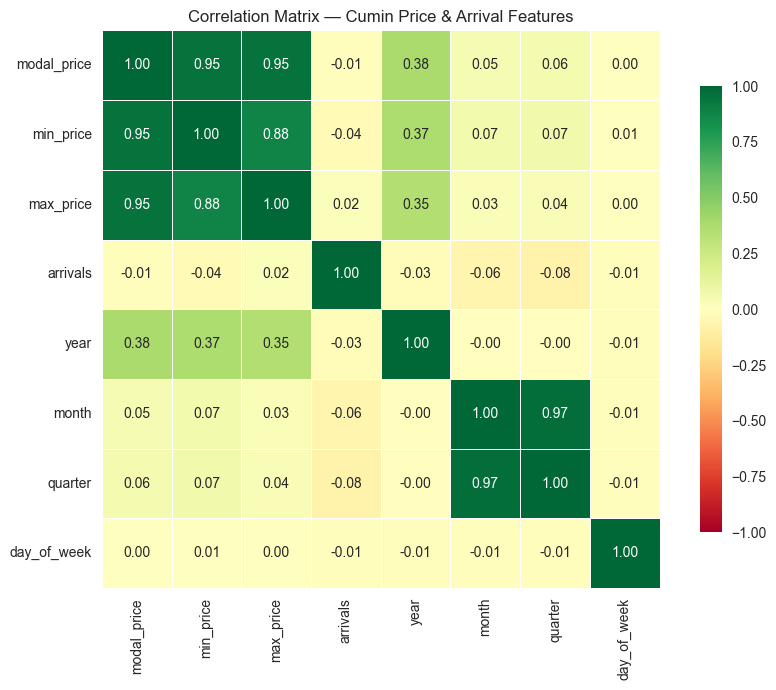

=== Top Correlations with modal_price ===
modal_price    1.00
max_price      0.95
min_price      0.95
year           0.38
quarter        0.06
month          0.05
day_of_week    0.00
arrivals      -0.01


In [19]:
numeric_cols = ['modal_price', 'min_price', 'max_price', 'arrivals',
                'year', 'month', 'quarter', 'day_of_week']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Cumin Price & Arrival Features', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Top Correlations with modal_price ===")
print(corr['modal_price'].sort_values(ascending=False).to_string())

IQR bounds: ₹-1882 — ₹37538
Outlier count: 3133 (6.5% of data)

Outlier price range: ₹37550 — ₹90000

Outliers by year:
year
2021       1
2023    3098
2024      34
dtype: int64

Outliers by state:
state
Gujarat           2419
Rajasthan          530
Maharashtra        171
Madhya Pradesh      13
dtype: int64


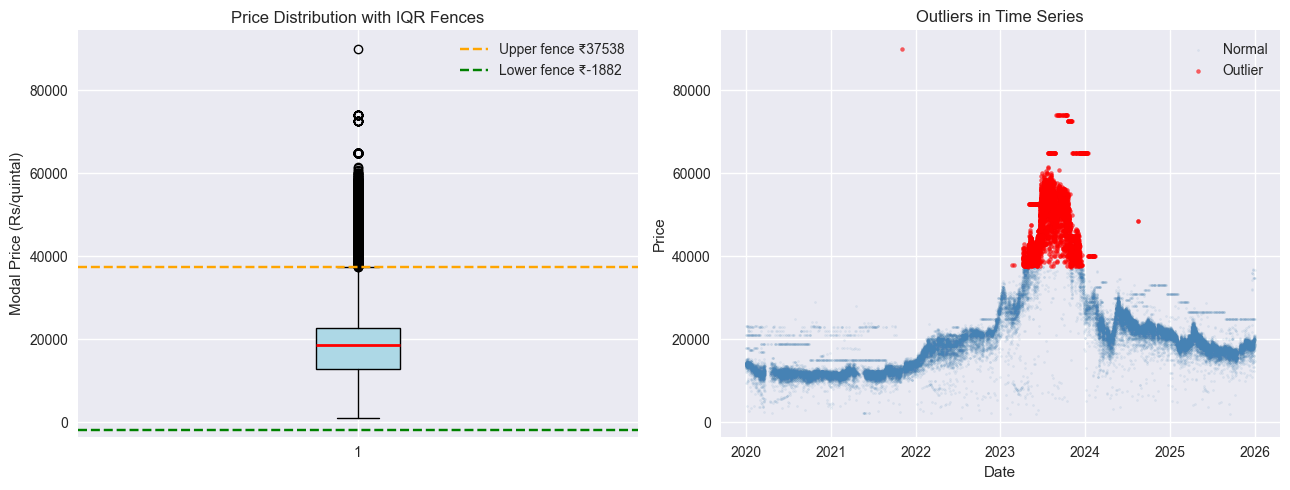

In [20]:
Q1 = df['modal_price'].quantile(0.25)
Q3 = df['modal_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['modal_price'] < lower) | (df['modal_price'] > upper)]

print(f"IQR bounds: ₹{lower:.0f} — ₹{upper:.0f}")
print(f"Outlier count: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")
print(f"\nOutlier price range: ₹{outliers['modal_price'].min():.0f} — ₹{outliers['modal_price'].max():.0f}")
print(f"\nOutliers by year:\n{outliers.groupby('year').size()}")
print(f"\nOutliers by state:\n{outliers.groupby('state').size().sort_values(ascending=False)}")  # ← fixed

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(df['modal_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].axhline(upper, color='orange', linestyle='--', label=f'Upper fence ₹{upper:.0f}')
axes[0].axhline(lower, color='green',  linestyle='--', label=f'Lower fence ₹{lower:.0f}')
axes[0].set_title('Price Distribution with IQR Fences')
axes[0].set_ylabel('Modal Price (Rs/quintal)')
axes[0].legend()

axes[1].scatter(df['date'], df['modal_price'], alpha=0.1, s=2, color='steelblue', label='Normal')
axes[1].scatter(outliers['date'], outliers['modal_price'], alpha=0.6, s=8, color='red', label='Outlier')
axes[1].set_title('Outliers in Time Series')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Price')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("=" * 60)
print("EDA SUMMARY — CUMIN PRICE & ARRIVAL DATA")
print("=" * 60)
print(f"\nDataset     : {df.shape[0]:,} records, {df.shape[1]} columns")
print(f"Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"States      : {df['state'].nunique()} ({', '.join(df['state'].unique())})")  # ← fixed
print(f"Markets     : {df['market'].nunique()} unique")                               # ← fixed
print(f"Varieties   : {df['variety'].nunique()} types")

print(f"\nPrice stats (modal_price):")
print(df['modal_price'].describe().round(0).to_string())

print(f"\nArrival stats (MT):")
print(df['arrivals'].describe().round(2).to_string())                                 # ← fixed

print(f"\nKey insights:")
print(f"  - 2023 price spike max   : ₹{df[df['year']==2023]['modal_price'].max():.0f}")
print(f"  - Peak arrival month     : {df.groupby('month')['arrivals'].mean().idxmax()} (March)")
print(f"  - Highest price month    : {df.groupby('month')['modal_price'].mean().idxmax()}")
print(f"  - Outliers (IQR)         : {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print(f"  - Gujarat share          : {(df['state']=='Gujarat').mean()*100:.1f}%")    # ← fixed
print(f"  - Rajasthan share        : {(df['state']=='Rajasthan').mean()*100:.1f}%")  # ← fixed
print("=" * 60)

EDA SUMMARY — CUMIN PRICE & ARRIVAL DATA

Dataset     : 48,141 records, 17 columns
Date range  : 2020-01-01 → 2025-12-31
States      : 10 (Gujarat, Maharashtra, Rajasthan, Kerala, Karnataka, Chattisgarh, Uttar Pradesh, Madhya Pradesh, Uttarakhand, Assam)
Markets     : 127 unique
Varieties   : 9 types

Price stats (modal_price):
count   48141.00
mean    20192.00
std      9390.00
min      1000.00
25%     12900.00
50%     18725.00
75%     22755.00
max     90000.00

Arrival stats (MT):
count   48141.00
mean       40.63
std       145.82
min         0.01
25%         0.90
50%         3.93
75%        20.40
max      8311.10

Key insights:
  - 2023 price spike max   : ₹74000
  - Peak arrival month     : 3 (March)
  - Highest price month    : 5
  - Outliers (IQR)         : 3133 rows (6.5%)
  - Gujarat share          : 72.6%
  - Rajasthan share        : 22.7%
✅ EDA COMPLETE — proceed to 02_preprocessing.ipynb
